### Introduction to Probability and Statistics

In [1]:
# Importing the necessary liabries
import numpy as np
import pandas as pd 
import random
import matplotlib.pyplot as plt

#### Random Variables and Distributions

In [2]:
#  drawing a sample of 30 values from a uniform distribution from 0 to 9
# also compute mean and variance.
sample = [ random.randint(0,10) for i in range(30) ]
print(f"Sample: {sample}")
print(f"mean: {np.mean(sample)}")
print(f"Variance: {np.var(sample)}")

Sample: [4, 5, 8, 9, 4, 5, 4, 3, 7, 6, 9, 9, 3, 2, 4, 7, 10, 8, 0, 10, 8, 3, 2, 7, 0, 5, 8, 7, 4, 7]
mean: 5.6
Variance: 7.64


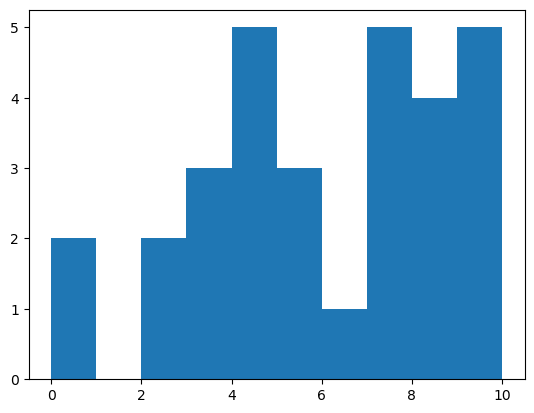

In [3]:
# Lets visualise the data using histogrm
plt.hist(sample)
plt.show()

#### Analyzing Real Data

In [24]:
# Loading the dataset directly from github
# We use pandas

url = "https://raw.githubusercontent.com/microsoft/Data-Science-For-Beginners/main/data/SOCR_MLB.tsv"

df = pd.read_csv(
    url, 
    sep='\t', 
    header=None, 
    names=['Name', 'Team', 'Role', 'Weight', 'Height', 'Age']
)

# check first 5 raws
print(df.head())

              Name Team           Role  Weight  Height    Age
0    Adam_Donachie  BAL        Catcher      74   180.0  22.99
1        Paul_Bako  BAL        Catcher      74   215.0  34.69
2  Ramon_Hernandez  BAL        Catcher      72   210.0  30.78
3     Kevin_Millar  BAL  First_Baseman      72   210.0  35.43
4      Chris_Gomez  BAL  First_Baseman      73   188.0  35.71


In [25]:
# Let's compute average values for age, height and weight:
df[["Age", "Height", "Weight"]].mean()

Age        28.736712
Height    201.689255
Weight     73.697292
dtype: float64

In [9]:
# lets print the first 20 values of Height
print(list(df["Height"])[:20])

[180.0, 215.0, 210.0, 210.0, 188.0, 176.0, 209.0, 200.0, 231.0, 180.0, 188.0, 180.0, 185.0, 160.0, 180.0, 185.0, 197.0, 189.0, 185.0, 219.0]


In [10]:
# Lets  compute standard deviation and variance of Height
mean = df["Height"].mean()
var = df["Height"].var()
std = df["Height"].std()

print(f"Mean: {mean}\nVariance: {var}\nStandard Deviation: {std}")

Mean: 201.6892545982575
Variance: 440.6426848120547
Standard Deviation: 20.991490771549664


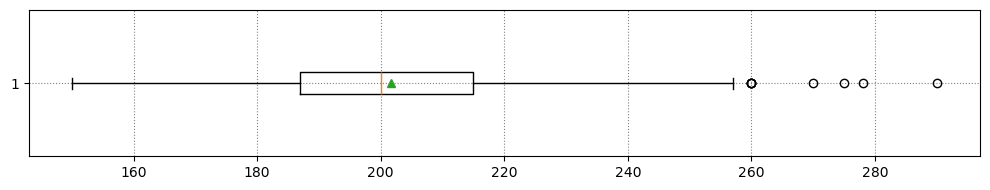

In [11]:
# lets visualise the median and quartiles values of Height using box plot:
plt.figure(figsize=(10,2))
plt.boxplot(df["Height"].ffill(), orientation="horizontal", showmeans=True)
plt.grid(color="gray", linestyle="dotted")
plt.tight_layout()
plt.show()

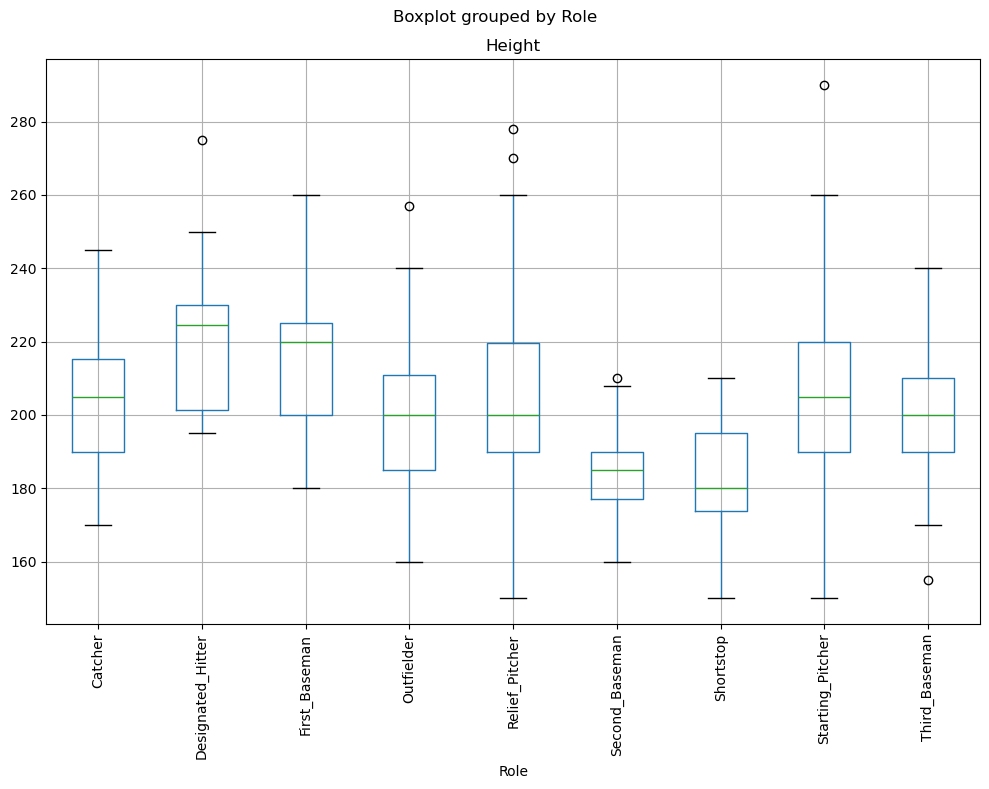

In [12]:
# make box plots of subsets of our dataset, for example, grouped by player role.
df.boxplot(column="Height", by="Role", figsize=(10,8))
plt.xticks(rotation="vertical")
plt.tight_layout()
plt.show()

##### Note: This diagram suggests, that on average, the heights of first basemen are higher than heights of second basemen.
##### Age, height and weight are all continuous random variables.

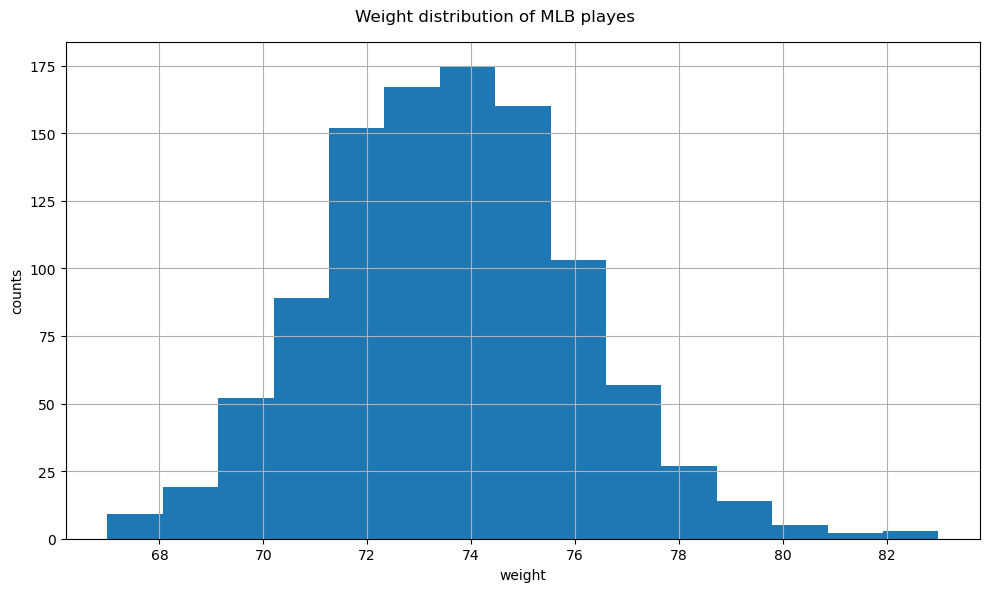

In [14]:
# lets plot the histogram of weights values
df["Weight"].hist(bins=15, figsize=(10,6))
plt.suptitle("Weight distribution of MLB playes")
plt.xlabel("weight")
plt.ylabel("counts")
plt.tight_layout()
plt.show()

#### Normal Distribution

###### Let's create an artificial sample of weights that follows a normal distribution with the same mean and variance as our real data:

In [15]:
generated = np.random.normal(mean, std,1000)
generated[:20]

array([219.52443001, 212.05313838, 213.05490455, 223.66941102,
       207.90081653, 246.27121387, 184.00521832, 201.4126414 ,
       177.91475175, 196.61835964, 206.33954521, 189.95690856,
       195.70976383, 198.73172551, 215.34246283, 223.72648689,
       209.86790966, 223.57605584, 190.91066912, 188.90131464])

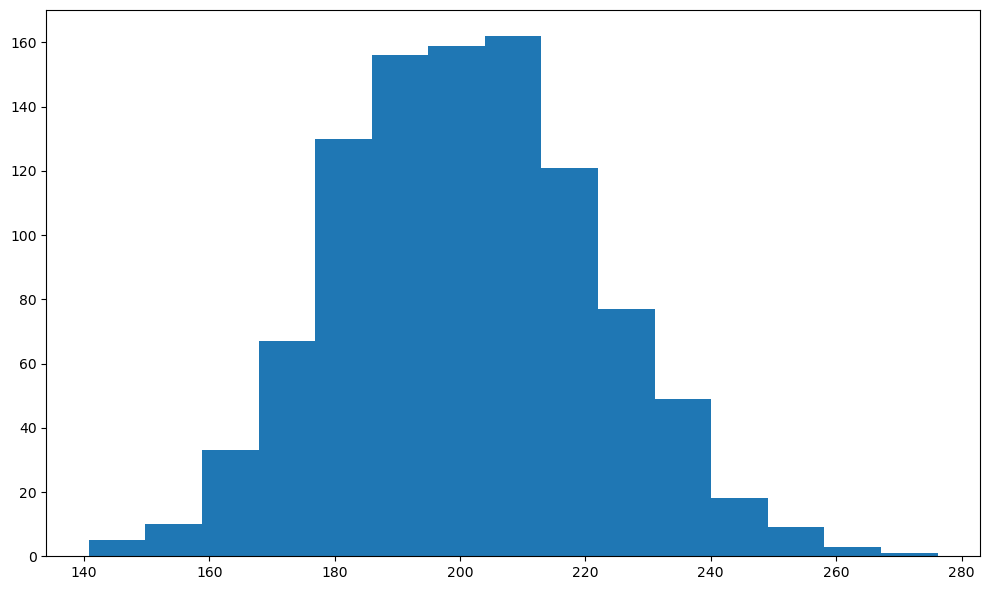

In [16]:
# Plot histogram of the generated sample
plt.figure(figsize=(10,6))
plt.hist(generated, bins=15)
plt.tight_layout()
plt.show()

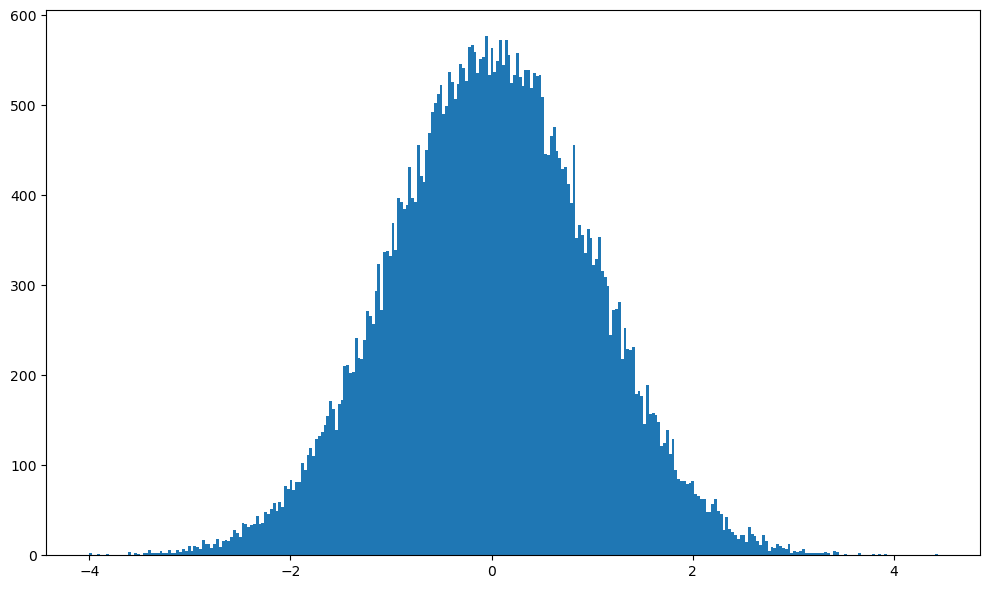

In [17]:
plt.figure(figsize=(10,6))
plt.hist(np.random.normal(0,1,50000), bins=300)
plt.tight_layout()
plt.show()

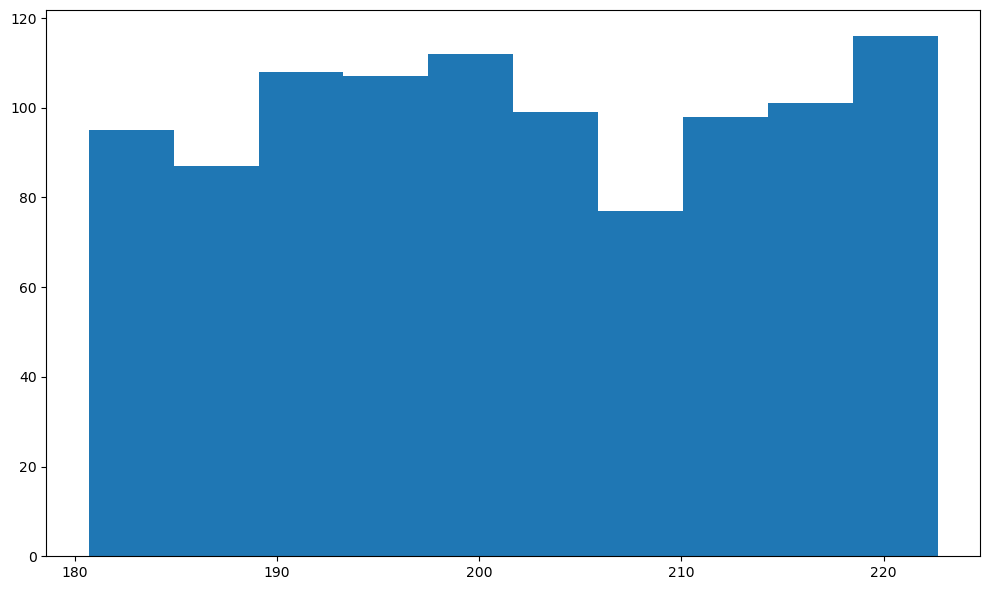

In [20]:
# we should not use a uniform random number generator to generate sample data
wrong_sample = np.random.rand(1000)*2*std+mean-std
plt.figure(figsize=(10,6))
plt.hist(wrong_sample)
plt.tight_layout()
plt.show()

#### Confidence Intervals

In [21]:
# Let's now calculate confidence intervals for the weights and heights of baseball players.
import scipy.stats

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h

for p in [0.85, 0.9, 0.95]:
    m, h = mean_confidence_interval(df['Weight'].ffill(),p)
    print(f"p={p:.2f}, mean = {m:.2f} ± {h:.2f}")


p=0.85, mean = 73.70 ± 0.10
p=0.90, mean = 73.70 ± 0.12
p=0.95, mean = 73.70 ± 0.14


#### Hypothesis Testing

In [23]:
# Let's explore different roles in our baseball players dataset:
# first rename the age clolumn to count
df.groupby("Role").agg({"Weight":"mean","Height":"mean","Age":"count"}).rename(columns={"Age":"Count"})

,Weight,Height,Count
Role,,,
Catcher,72.723684,204.328947,76
Designated_Hitter,74.222222,220.888889,18
First_Baseman,74.000000,213.109091,55
Outfielder,73.010309,199.113402,194
Relief_Pitcher,74.374603,203.517460,315
Second_Baseman,71.362069,184.344828,58
Shortstop,71.903846,182.923077,52
Starting_Pitcher,74.719457,205.163636,221
Third_Baseman,73.044444,200.955556,45


In [27]:
# Let's test the hypothesis that First Basemen are taller than Second Basemen.
# by testing the confidence interval

for p in [0.85,0.9,0.95]:
    m1, h1 = mean_confidence_interval(df.loc[df['Role']=='First_Baseman',['Height']],p)
    m2, h2 = mean_confidence_interval(df.loc[df['Role']=='Second_Baseman',['Height']],p)
    print(f'Conf={p:.2f}, 1st basemen height: {m1-h1[0]:.2f}..{m1+h1[0]:.2f},2nd basemen height: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}')

Conf=0.85, 1st basemen height: 209.36..216.86,2nd basemen height: 182.24..186.45
Conf=0.90, 1st basemen height: 208.82..217.40,2nd basemen height: 181.93..186.76
Conf=0.95, 1st basemen height: 207.97..218.25,2nd basemen height: 181.45..187.24


##### intervals do not overlap

In [29]:
# lets prove the hypothesis by using Student t-test
from scipy.stats import ttest_ind

tval, pval = ttest_ind(df.loc[df['Role']=='First_Baseman',['Height']], df.loc[df['Role']=='Second_Baseman',['Height']],equal_var=False)
print(f"T-value = {tval[0]:.2f}\nP-value: {pval[0]}")

T-value = 9.77
P-value: 1.4185554184322326e-15


##### The two values returned by the ttest_ind function are:
###### 1.p-value can be considered as the probability of two distributions having the same mean. 
###### 2.t-value is the intermediate value of normalized mean difference that is used in the t-test, and it is compared against a threshold value for a given confidence value.

#### Simulating a Normal Distribution with the Central Limit Theorem

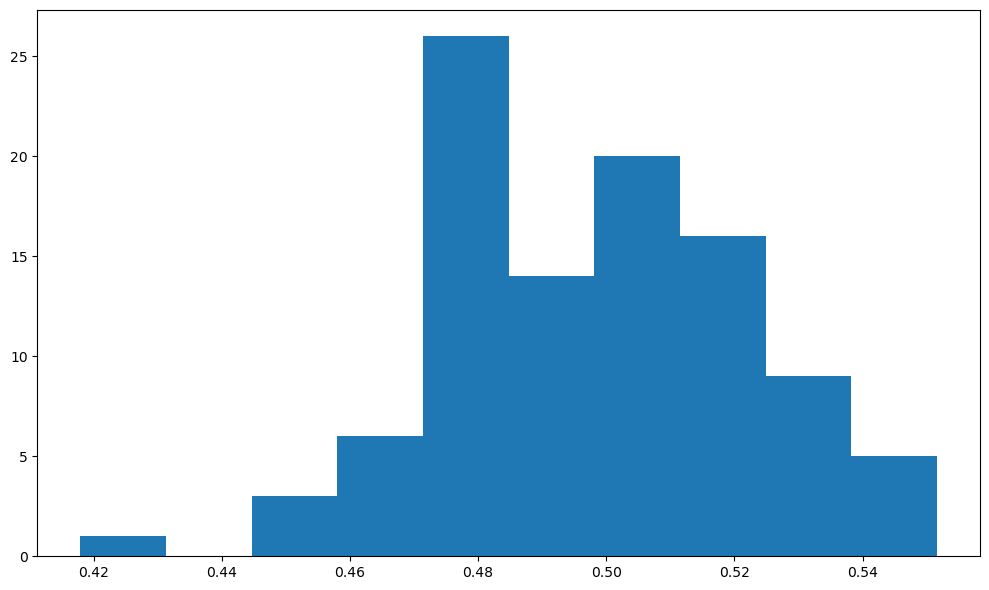

In [31]:
# use the central limit theorem to generate normal distribution

def normal_random(sample_size=100):
    sample = [random.uniform(0,1) for _ in range(sample_size)]
    return sum(sample)/sample_size

sample = [normal_random() for _ in range(100)]
plt.figure(figsize=(10,6))
plt.hist(sample)
plt.tight_layout()
plt.show()

#### Correlation and Evil Baseball Corp
###### Correlation allows us to find relations between data sequences.

In [32]:
# lets compute the imaginary salary of players depending on height
heights = df["Height"].ffill()
salaries = 1000+(heights-heights.min())/(heights.max()-heights.mean())*100
print(list(zip(heights, salaries))[:10])

[(180.0, 1033.985209531635), (215.0, 1073.6346206518763), (210.0, 1067.9704190632704), (210.0, 1067.9704190632704), (188.0, 1043.0479320734046), (176.0, 1029.4538482607504), (209.0, 1066.837578745549), (200.0, 1056.6420158860585), (231.0, 1091.760065735415), (180.0, 1033.985209531635)]


In [34]:
# Let's now compute covariance and correlation of those sequences.
print(f"Covariance matrix:\n{np.cov(heights, salaries)}")
print(f"Covariance = {np.cov(heights, salaries)[0,1]}")
print(f"Correlation = {np.corrcoef(heights, salaries)[0,1]}")

Covariance matrix:
[[441.63557066 500.30258018]
 [500.30258018 566.76293389]]
Covariance = 500.30258017867226
Correlation = 0.9999999999999988


##### A correlation equal to 1 means that there is a strong linear relation between two variables. We can visually see the linear relation by plotting one value against the other:

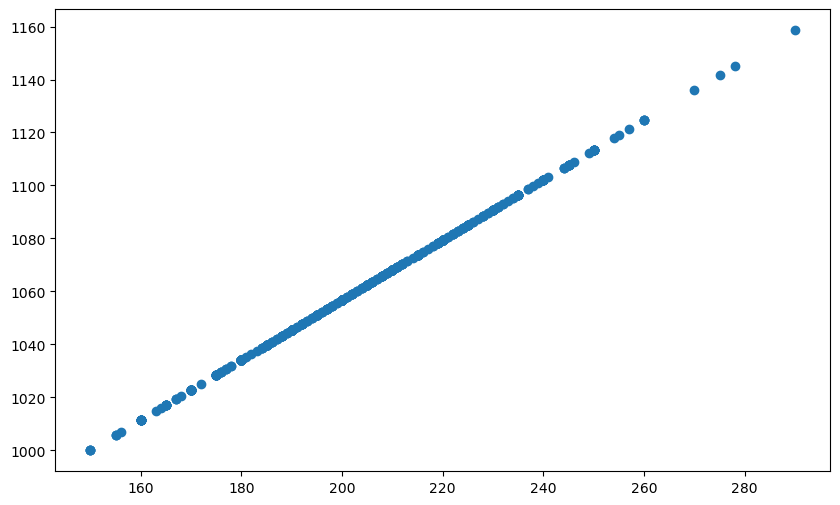

In [35]:
# lets use scatter plots 
plt.figure(figsize=(10,6))
plt.scatter(heights,salaries)
plt.show()

###### Let's see what happens if the relation is not linear. Suppose that our corporation decided to hide the obvious linear dependency between heights and salaries, and introduced some non-linearity into the formula, such as sin:

In [36]:
# lets introduce sin to make the relatin non-linear
salaries = 1000+np.sin((heights-heights.min())/(heights.max()-heights.mean()))
print(f"Correlation = {np.corrcoef(heights,salaries)[0,1]}")

Correlation = 0.9910655775558497


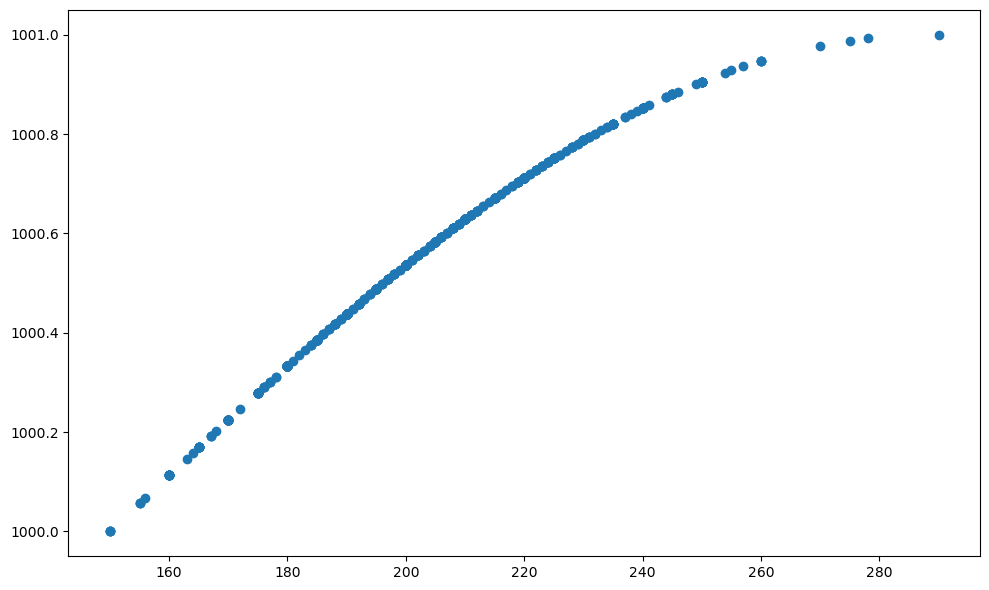

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(heights, salaries)
plt.tight_layout()
plt.show()

In [38]:
# lets find the correlation between height and Weight
np.corrcoef(df["Height"].ffill(),df["Weight"])

array([[1.        , 0.52959196],
       [0.52959196, 1.        ]])

In [41]:
# Let's use fillna method to fill the missing values, and compute the correlation:
# Fill missing values in Height with the mean height
height_filled = df["Height"].fillna(df["Height"].mean())
weight_filled = df["Weight"].fillna(df["Weight"].mean())

# Compute correlation coefficient matrix
correlation_matrix = np.corrcoef(height_filled, weight_filled)
correlation_coefficient = correlation_matrix[0, 1]

print("Correlation Coefficient:", correlation_coefficient)

Correlation Coefficient: 0.5317462170721952


#### By Owili Peter